In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings

warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [4]:
master_df = pd.read_csv(
    "../data/processed/featured_dataset.csv"
)

master_df['DATE_TIME'] = pd.to_datetime(
    master_df['DATE_TIME']
)

print("Dataset loaded successfully")

display(master_df.head())

Dataset loaded successfully


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,HOUR,DAY,MONTH,DAY_OF_WEEK,WEEK_OF_YEAR,IS_PEAK_HOUR,TEMP_DIFFERENCE,IRRADIATION_EFFICIENCY,PREVIOUS_AC_POWER,ROLLING_MEAN_AC_POWER
0,2020-05-15,4136001,LYwnQax7tkwH5Cb,0.0,0.0,1872.500000,1.794959e+09,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
1,2020-05-15,4136001,LlT2YUhhzqhg5Sw,0.0,0.0,1094.357143,2.825928e+08,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
2,2020-05-15,4136001,Mx2yZCDsyf6DPfv,0.0,0.0,5692.200000,2.453646e+06,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
3,2020-05-15,4136001,NgDl19wMapZy17u,0.0,0.0,1866.200000,1.115126e+08,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0
4,2020-05-15,4136001,PeE6FRyGXUgsRhN,0.0,0.0,651.200000,1.348351e+09,27.004764,25.060789,0.0,0,15,5,4,20,0,-1.943975,0.0,0.0,0.0


In [5]:
features_df = master_df.drop(
    columns=[
        'DATE_TIME',
        'SOURCE_KEY',
        'AC_POWER',
        'DC_POWER'
    ]
)

target = master_df['AC_POWER']

print("Feature columns prepared")

print(features_df.columns)

Feature columns prepared
Index(['PLANT_ID', 'DAILY_YIELD', 'TOTAL_YIELD', 'AMBIENT_TEMPERATURE',
       'MODULE_TEMPERATURE', 'IRRADIATION', 'HOUR', 'DAY', 'MONTH',
       'DAY_OF_WEEK', 'WEEK_OF_YEAR', 'IS_PEAK_HOUR', 'TEMP_DIFFERENCE',
       'IRRADIATION_EFFICIENCY', 'PREVIOUS_AC_POWER', 'ROLLING_MEAN_AC_POWER'],
      dtype='str')


In [6]:
split_index = int(len(features_df) * 0.8)

X_train = features_df.iloc[:split_index]

X_test = features_df.iloc[split_index:]

y_train = target.iloc[:split_index]

y_test = target.iloc[split_index:]

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (109175, 16)
Testing Shape: (27294, 16)


In [7]:
def evaluate_model(
    model_name,
    y_true,
    y_pred
):
    
    mae = mean_absolute_error(
        y_true,
        y_pred
    )
    
    mse = mean_squared_error(
        y_true,
        y_pred
    )
    
    rmse = np.sqrt(mse)
    
    r2 = r2_score(
        y_true,
        y_pred
    )
    
    return {
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    }

In [8]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)

linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

print(linear_results)

{'Model': 'Linear Regression', 'MAE': 44.89061252155262, 'RMSE': np.float64(79.61030418293282), 'R2 Score': 0.9413228407069056}


In [9]:
decision_tree_model = DecisionTreeRegressor(
    random_state=42
)

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_predictions = (
    decision_tree_model.predict(X_test)
)

decision_tree_results = evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_predictions
)

print(decision_tree_results)

{'Model': 'Decision Tree', 'MAE': 2.7418416009591677, 'RMSE': np.float64(10.464507054983454), 'R2 Score': 0.9989861631698469}


In [10]:
random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = (
    random_forest_model.predict(X_test)
)

random_forest_results = evaluate_model(
    "Random Forest",
    y_test,
    random_forest_predictions
)

print(random_forest_results)

{'Model': 'Random Forest', 'MAE': 1.2630609159848363, 'RMSE': np.float64(5.537639794959051), 'R2 Score': 0.999716090503432}


In [11]:
xgboost_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42
)

xgboost_model.fit(
    X_train,
    y_train
)

xgboost_predictions = (
    xgboost_model.predict(X_test)
)

xgboost_results = evaluate_model(
    "XGBoost",
    y_test,
    xgboost_predictions
)

print(xgboost_results)

{'Model': 'XGBoost', 'MAE': 2.966762878822295, 'RMSE': np.float64(7.971458046354085), 'R2 Score': 0.999411690253638}


In [12]:
results_df = pd.DataFrame([
    linear_results,
    decision_tree_results,
    random_forest_results,
    xgboost_results
])

display(results_df)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,44.890613,79.610304,0.941323
1,Decision Tree,2.741842,10.464507,0.998986
2,Random Forest,1.263061,5.537640,0.999716
3,XGBoost,2.966763,7.971458,0.999412


In [13]:
results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

display(results_df)

,Model,MAE,RMSE,R2 Score
2,Random Forest,1.263061,5.537640,0.999716
3,XGBoost,2.966763,7.971458,0.999412
1,Decision Tree,2.741842,10.464507,0.998986
0,Linear Regression,44.890613,79.610304,0.941323


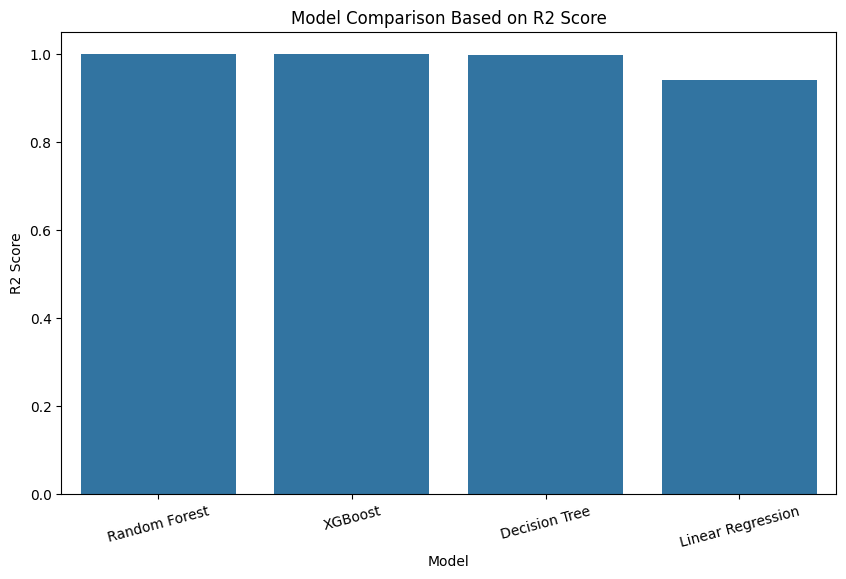

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results_df
)

plt.title("Model Comparison Based on R2 Score")

plt.xticks(rotation=15)

plt.show()

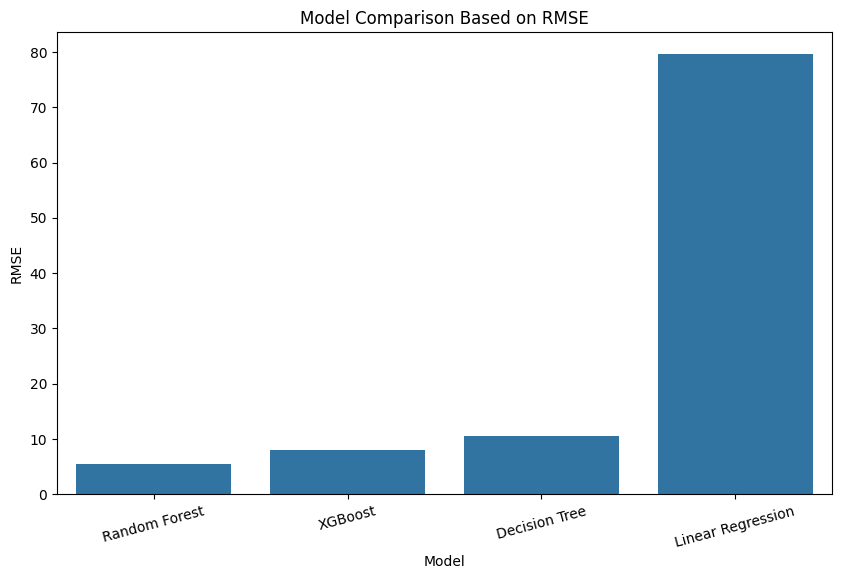

In [15]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='RMSE',
    data=results_df
)

plt.title("Model Comparison Based on RMSE")

plt.xticks(rotation=15)

plt.show()

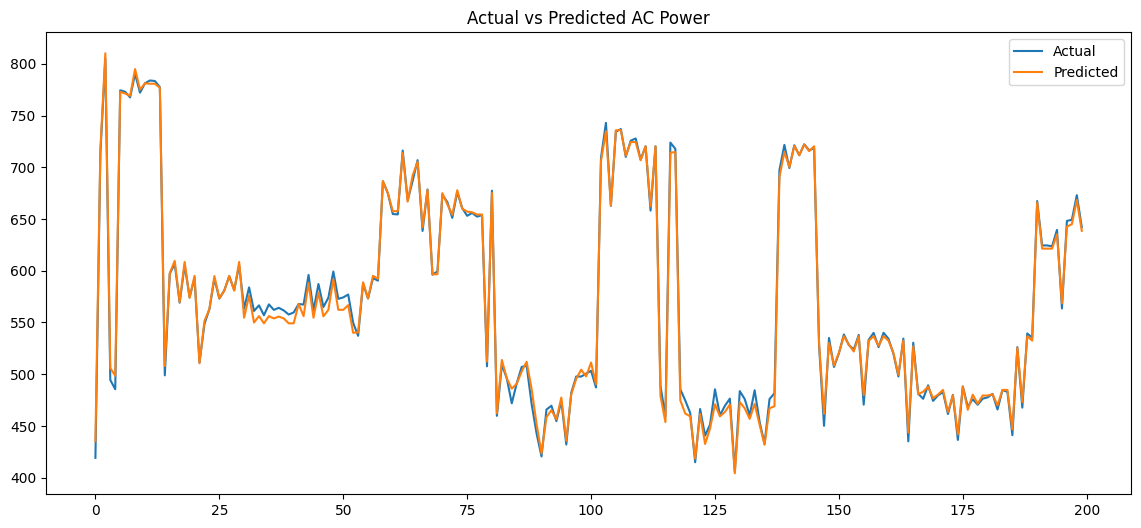

In [16]:
plt.figure(figsize=(14,6))

plt.plot(
    y_test.values[:200],
    label='Actual'
)

plt.plot(
    xgboost_predictions[:200],
    label='Predicted'
)

plt.title("Actual vs Predicted AC Power")

plt.legend()

plt.show()

In [20]:
import plotly.express as px

In [21]:
comparison_before = pd.DataFrame({

    'Actual': y_test.values[:100],

    'Linear Regression': linear_predictions[:100],

    'Random Forest': random_forest_predictions[:100],

    'XGBoost': xgboost_predictions[:100],

    'Decision Tree': decision_tree_predictions[:100]
})

fig = px.line(

    comparison_before,

    title='Actual vs Models Before Hyperparameter Tuning'
)

fig.update_layout(

    xaxis_title='Sample Index',

    yaxis_title='AC Power'
)

fig.show()